如果使用 Pandas 输出含中文的表格时格式混乱，可以设置 display.unicode.east_asian_width 选项，确保正确对齐：

pd.set_option('display.unicode.east_asian_width',True)

【例3-1】检查缺失值及统计其个数

In [18]:
import pandas as pd
df = pd.DataFrame({'商品': ['苹果', '香蕉', '梨'],
                   '单价（元）': [5, 5, 4],
                   '销量（kg）': [100, None, None],
                   '库存（kg）': [50, None, 70]})
print('原始数据：\n', df)
df.isnull().sum()

原始数据：
    商品  单价（元）  销量（kg）  库存（kg）
0  苹果           5       100.0        50.0
1  香蕉           5         NaN         NaN
2    梨           4         NaN        70.0


商品          0
单价（元）    0
销量（kg）    2
库存（kg）    1
dtype: int64

【例3-2】删除缺失值

In [19]:
import pandas as pd
df = pd.DataFrame({'商品': ['苹果', '香蕉', '梨'],
                   '单价（元）': [5, 5, 4],
                   '销量（kg）': [100, None, None],
                   '库存（kg）': [50, None, 70]})
print('原始数据：\n', df)
df.dropna()


原始数据：
    商品  单价（元）  销量（kg）  库存（kg）
0  苹果           5       100.0        50.0
1  香蕉           5         NaN         NaN
2    梨           4         NaN        70.0


,商品,单价（元）,销量（kg）,库存（kg）
0,苹果,5,100.0,50.0


【例3-3】替换缺失值

In [4]:
df = pd.DataFrame({'商品': ['苹果', '香蕉', '梨'],
                   '单价（元）': [5, 5, 4],
                   '销量（kg）': [100, None, None],
                   '库存（kg）': [50, None, 70]})
print('原始数据：\n', df)

原始数据：
    商品  单价（元）  销量（kg）  库存（kg）
0  苹果      5   100.0    50.0
1  香蕉      5     NaN     NaN
2   梨      4     NaN    70.0


【例3-4】检查重复值

In [20]:
df = pd.DataFrame({'商品': ['苹果', '香蕉', '梨', '香蕉'],
                   '单价（元）': [4, 5, 4, 5],
                   '销量（kg）': [100, 120, 105, 120],
                   '库存（kg）': [50, 60, 70, 60]})
print('原始数据：\n', df)
df.duplicated()

原始数据：
    商品  单价（元）  销量（kg）  库存（kg）
0  苹果           4         100          50
1  香蕉           5         120          60
2    梨           4         105          70
3  香蕉           5         120          60


0    False
1    False
2    False
3     True
dtype: bool

【例3-5】删除重复值

In [21]:
df = pd.DataFrame({'商品': ['苹果', '香蕉', '梨', '香蕉'],
                   '单价（元）': [4, 5, 4, 5],
                   '销量（kg）': [100, 120, 105, 120],
                   '库存（kg）': [50, 60, 70, 60]})
print('原始数据：\n', df)
df.drop_duplicates()

原始数据：
    商品  单价（元）  销量（kg）  库存（kg）
0  苹果           4         100          50
1  香蕉           5         120          60
2    梨           4         105          70
3  香蕉           5         120          60


,商品,单价（元）,销量（kg）,库存（kg）
0,苹果,4,100,50
1,香蕉,5,120,60
2,梨,4,105,70


【例】异常值

In [24]:
import pandas as pd
%matplotlib inline
df = pd.DataFrame({'A': [1, 2, 3, 4],
                   'B': [2, 3, 5, 2],
                   'C': [1, 4, 7, 4],
                   'D': [1, 5, 30, 3]})
df


,A,B,C,D
0,1,2,1,1
1,2,3,4,5
2,3,5,7,30
3,4,2,4,3


<Axes: >

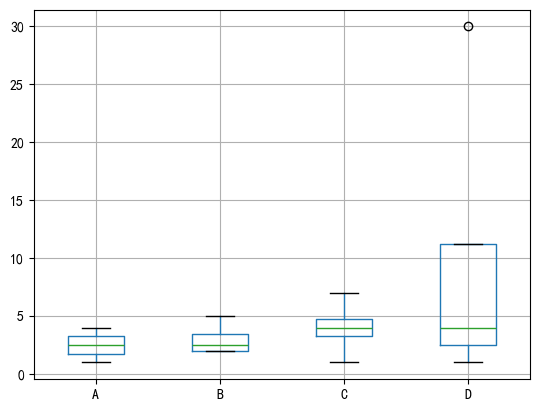

In [25]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
df.boxplot()

【例3-6】数据的横向合并

In [8]:
import numpy as np
import pandas as pd
arr = np.arange(1, 10).reshape(3, 3)
df1 = pd.DataFrame(arr, columns=['a', 'b', 'c'])
df1.insert(0, 'key', ['001', '003', '002'])
print('左对象原始数据df1：\n', df1)
arr2 = np.arange(10, 14).reshape(2, 2)
df2 = pd.DataFrame(arr2, columns=['a', 'e'])
df2.insert(0, 'key', ['001', '004'])
print('右对象原始数据df2：\n', df2)

左对象原始数据df1：
    key  a  b  c
0  001  1  2  3
1  003  4  5  6
2  002  7  8  9
右对象原始数据df2：
    key   a   e
0  001  10  11
1  004  12  13


In [9]:
pd.merge(df1,df2,on='key')

,key,a_x,b,c,a_y,e
0,001,1,2,3,10,11


【例3-7】数据的纵向合并

In [10]:
import numpy as np
import pandas as pd
arr1 = np.arange(1, 10).reshape(3, 3)
df1 = pd.DataFrame(arr1, columns=['a', 'b', 'c'])
df1.insert(0, 'key', ['001', '003', '002'])
print('第一个对象原始数据df1：\n', df1)
arr2 = np.arange(10, 14).reshape(2, 2)
df2 = pd.DataFrame(arr2, columns=['a', 'e'])
df2.insert(0, 'key', ['001', '004'])
print('第二个对象原始数据df2：\n', df2)

第一个对象原始数据df1：
    key  a  b  c
0  001  1  2  3
1  003  4  5  6
2  002  7  8  9
第二个对象原始数据df2：
    key   a   e
0  001  10  11
1  004  12  13


In [11]:
pd.concat([df1,df2],axis=0)

,key,a,b,c,e
0,001,1,2.0,3.0,NaN
1,003,4,5.0,6.0,NaN
2,002,7,8.0,9.0,NaN
0,001,10,NaN,NaN,11.0
1,004,12,NaN,NaN,13.0


【例3-9】数据的聚合

In [12]:
import numpy as np
import pandas as pd
arr = np.random.randint(1, 20, size=(3, 3))
df = pd.DataFrame(arr, columns=['a', 'b', 'c'])
print('原始数据：\n', df)

原始数据：
     a   b   c
0   5  17   5
1   2  14  17
2  19  18  13


【例3-10】数据的分组和聚合

In [13]:
import pandas as pd
pd.set_option('display.unicode.east_asian_width', True)
df = pd.DataFrame({'班级': ['一班', '一班', '一班', '二班', '二班', '二班'],
                   '姓名': ['刘武', '王振', '赵胜', '赵霞', '方芳', '齐婷'],
                   '语文': [85, 102, 96, 126, 130, 135],
                   '数学': [100, 90, 124, 123, 140, 109],
                   '英语': [83, 110, 123, 103, 135, 90]})
print('原始数据：\n', df)

原始数据：
    班级  姓名  语文  数学  英语
0  一班  刘武    85   100    83
1  一班  王振   102    90   110
2  一班  赵胜    96   124   123
3  二班  赵霞   126   123   103
4  二班  方芳   130   140   135
5  二班  齐婷   135   109    90
